Preprocessing
Import Libraries & set Random Seeds

In [1]:
# read & manipulate data
import pandas as pd 
import numpy as np
import tensorflow as tf

# visualisations
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')
%matplotlib notebook

# misc
import random as rn

# load the dataset
#df = pd.read_csv('../input/creditcard.csv')
#df = pd.read_csv('C:\Project\Journal\dataset\psa_journal_home_A_unsupervise_train.csv')
df = pd.read_csv('C:\\Users\\olufe\\projects\\Journal\\dataset\\HomeA_unsupervised_real_combined_data.csv')
#df = pd.read_csv('C:\\Users\\olufe\\projects\\Journal\\dataset\\HomeA_regrouped_data.csv')
#df = pd.read_csv('C:\\Users\\olufe\\projects\\Journal\\dataset\\psa_journal_home_A_unsupervise_train.csv')


In [2]:
df

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,...,M1371,M1372,M1373,M1374,M1375,M1376,M1377,M1378,M1379,Label
0,533,597,488,476,387,337,336,333,334,334,...,1055,1033,899,1084,755,436,426,391,407,0
1,371,367,521,508,496,500,490,489,482,491,...,982,376,414,415,416,412,560,571,560,0
2,1033,977,882,855,716,714,763,772,768,767,...,992,962,963,960,983,1108,940,953,932,0
3,466,466,466,462,463,338,338,344,340,368,...,336,337,338,337,339,339,373,336,343,0
4,333,328,336,335,334,333,336,338,336,334,...,1237,593,466,473,461,468,469,470,513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52555,414,414,412,415,410,284,287,284,284,290,...,380,370,369,325,297,286,287,287,429,0
52556,330,312,313,371,373,323,313,334,369,360,...,407,401,379,395,575,575,521,637,1040,1
52557,592,572,561,558,572,584,605,578,474,468,...,685,692,713,660,629,652,651,536,521,1
52558,1053,1146,1167,980,1089,1155,1111,1123,1134,1135,...,1154,1271,1033,1132,1109,989,918,1000,1001,1


In [3]:
# Undersampling the non-fraud
# To keep the computation time low, let's feed t-SNE only a small subsample (undersampling the clean transactions).

In [4]:
# manual parameters
RANDOM_SEED = 42
#TRAINING_SAMPLE = 200000
TRAINING_SAMPLE = 20000
VALIDATE_SIZE = 0.2

# setting random seeds for libraries to ensure reproducibility
#np.random.seed(RANDOM_SEED)
#rn.seed(RANDOM_SEED)
#
# Set the random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rn.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [5]:
# Converting columns to lower case
# let's quickly convert the columns to lower case and rename the Class column 
# so as to not cause syntax errors
df.columns = map(str.lower, df.columns)

#Renaming columns
#df.rename(columns={'class': 'label'}, inplace=True)

# print first 5 rows to get an initial impression of the data we're dealing with
df.head()

,m0,m1,m2,m3,m4,m5,m6,m7,m8,m9,...,m1371,m1372,m1373,m1374,m1375,m1376,m1377,m1378,m1379,label
0,533,597,488,476,387,337,336,333,334,334,...,1055,1033,899,1084,755,436,426,391,407,0
1,371,367,521,508,496,500,490,489,482,491,...,982,376,414,415,416,412,560,571,560,0
2,1033,977,882,855,716,714,763,772,768,767,...,992,962,963,960,983,1108,940,953,932,0
3,466,466,466,462,463,338,338,344,340,368,...,336,337,338,337,339,339,373,336,343,0
4,333,328,336,335,334,333,336,338,336,334,...,1237,593,466,473,461,468,469,470,513,0


In [6]:
# keep the label field at the back
df = df[
#    [col for col in df if col not in ['label', 'log10_amount']] + 
#    ['log10_amount', 'label']
    [col for col in df if col not in ['label']] + 
    ['label']
]

Visualising clusters with t-SNE

Undersampling the non-attack¶
To keep the computation time low, let's feed t-SNE only a small subsample (undersampling the benign transactions).

In [7]:
# manual parameter 
RATIO_TO_THEFT =2

# dropping redundant columns
#df = df.drop(['time', 'amount'], axis=1)

# splitting by class
theft = df[df.label == 1]
benign = df[df.label == 0]

# undersample clean transactions
benign_undersampled = benign.sample(
    int(len(theft) * RATIO_TO_THEFT),
    random_state=RANDOM_SEED
)

# concatenate with fraud transactions into a single dataframe
visualisation_initial = pd.concat([theft, benign_undersampled])
column_names = list(visualisation_initial.drop('label', axis=1).columns)

# isolate features from labels 
features, labels = visualisation_initial.drop('label', axis=1).values, \
                   visualisation_initial.label.values

In [8]:
print(f"""The non-theft dataset has been undersampled from {len(benign):,} to {len(benign_undersampled):,}.
This represents a ratio of {RATIO_TO_THEFT}:1 to theft.""")

The non-theft dataset has been undersampled from 43,800 to 17,520.
This represents a ratio of 2:1 to theft.


t-SNE output

In [9]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

def tsne_scatter(features, labels, dimensions=2, save_as='graph.png'):
    if dimensions not in (2, 3):
        raise ValueError('tsne_scatter can only plot in 2d or 3d (What are you? An alien that can visualise >3d?). Make sure the "dimensions" argument is in (2, 3)')

   # t-SNE dimensionality reduction
    features_embedded = TSNE(n_components=dimensions, random_state=RANDOM_SEED).fit_transform(features)
    
    # initialising the plot
    fig, ax = plt.subplots(figsize=(8,8))
    
    # counting dimensions
    if dimensions == 3: ax = fig.add_subplot(111, projection='3d')

    # plotting data
    ax.scatter(
        *zip(*features_embedded[np.where(labels==1)]),
        marker='o',
        color='r',
        s=2,
        alpha=0.7,
        label='Theft'
    )
    ax.scatter(
        *zip(*features_embedded[np.where(labels==0)]),
        marker='o',
        color='g',
        s=2,
        alpha=0.3,
        label='Benign'
    )

    # storing it to be displayed later
    plt.legend(loc='best')
    #plt.savefig(save_as);
    plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_combined_data.png',bbox_inches='tight')
    plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_combined_data.eps',bbox_inches='tight')
    plt.show;

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


<IPython.core.display.Javascript object>


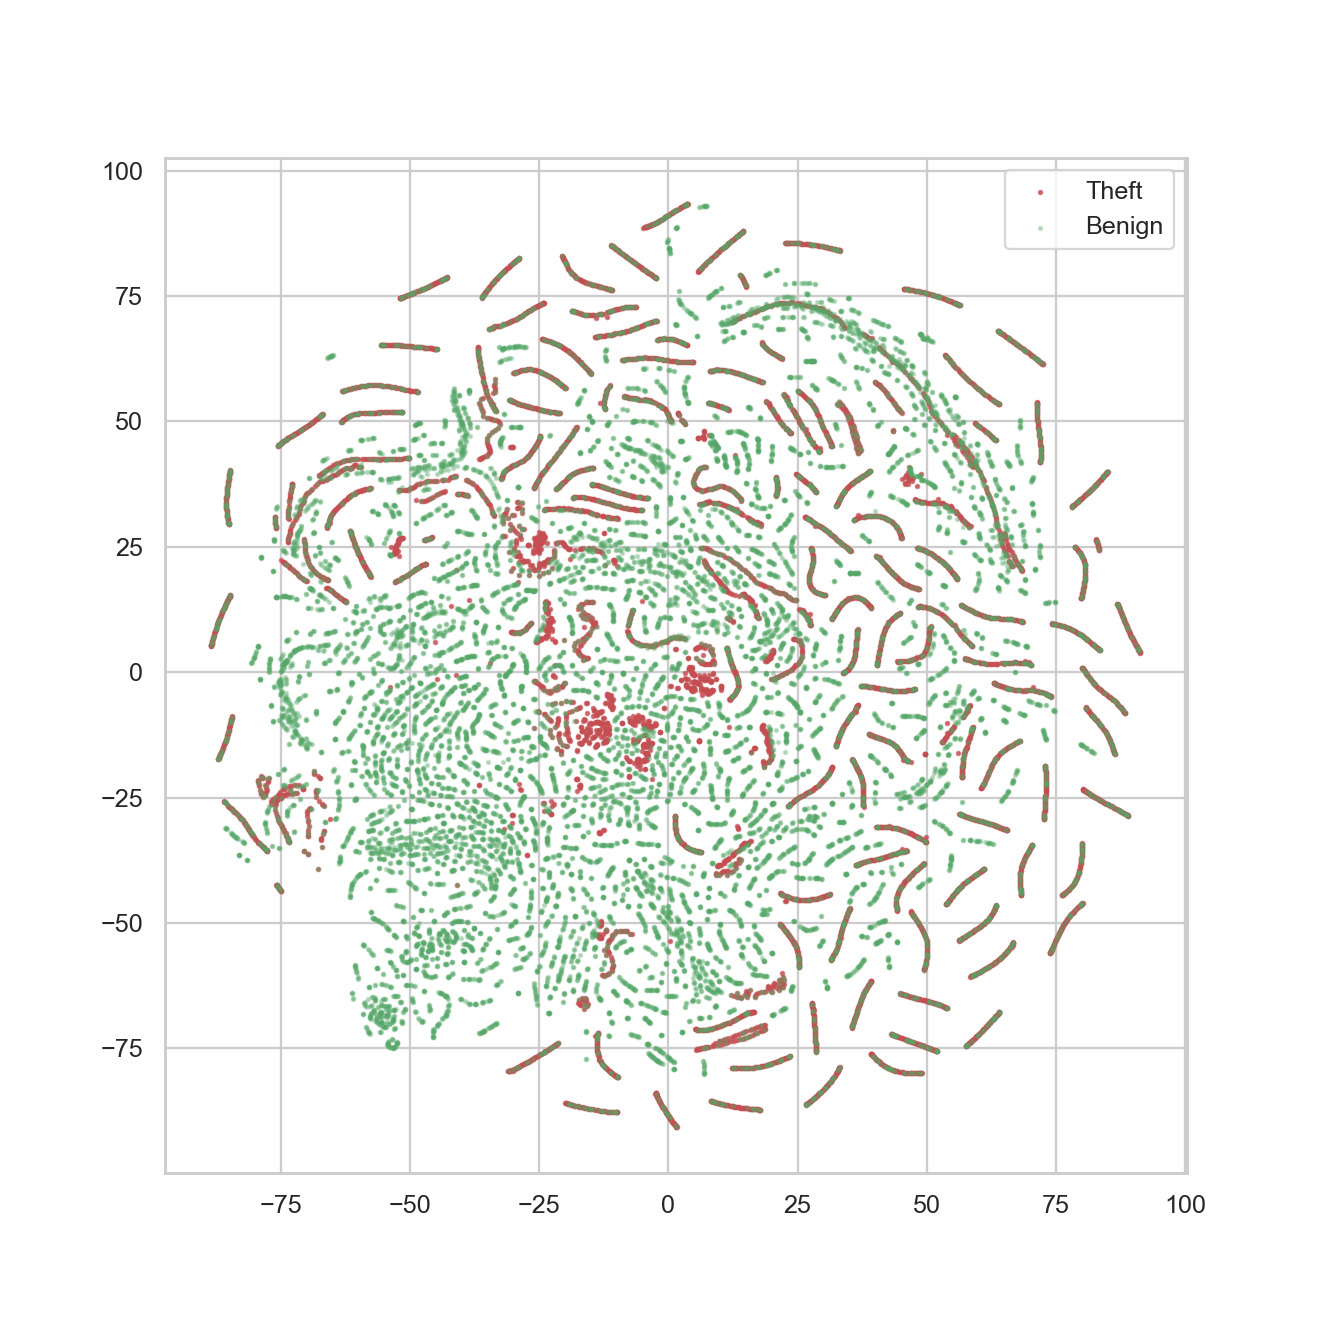

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [10]:
tsne_scatter(features, labels, dimensions=2, save_as='tsne_initial_2d.png')

In [11]:
print(f"""Shape of the datasets:
    benign (rows, cols) = {benign.shape}
    theft (rows, cols) = {theft.shape}""")

Shape of the datasets:
    benign (rows, cols) = (43800, 1381)
    theft (rows, cols) = (8760, 1381)


In [12]:
# shuffle our training set
benign = benign.sample(frac=1).reset_index(drop=True)

# training set: exlusively non-fraud transactions
X_train = benign.iloc[:TRAINING_SAMPLE].drop('label', axis=1)

# testing  set: the remaining non-fraud + all the fraud 
X_test = benign.iloc[TRAINING_SAMPLE:].append(theft).sample(frac=1)

C:\Users\olufe\AppData\Local\Temp\ipykernel_22428\2446658722.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  X_test = benign.iloc[TRAINING_SAMPLE:].append(theft).sample(frac=1)


In [13]:
print(f"""Our testing set is composed as follows:

{X_test.label.value_counts()}""")

Our testing set is composed as follows:

0    23800
1     8760
Name: label, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

# train // validate - no labels since they're all clean anyway
X_train, X_validate = train_test_split(X_train, 
                                       test_size=VALIDATE_SIZE, 
                                       random_state=RANDOM_SEED)

# manually splitting the labels from the test df
X_test, y_test = X_test.drop('label', axis=1).values, X_test.label.values

Summary

In [15]:
print(f"""Shape of the datasets:
    training (rows, cols) = {X_train.shape}
    validate (rows, cols) = {X_validate.shape}
    holdout  (rows, cols) = {X_test.shape}""")

Shape of the datasets:
    training (rows, cols) = (16000, 1380)
    validate (rows, cols) = (4000, 1380)
    holdout  (rows, cols) = (32560, 1380)


Normalising & Standardising

Building our pipeline

In [16]:
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline

# configure our pipeline
pipeline = Pipeline([('normalizer', Normalizer()),
                     ('scaler', MinMaxScaler())])

Fitting the pipeline

In [17]:
# get normalization parameters by fitting to the training data
pipeline.fit(X_train);

Applying transformations with acquired parameters

In [18]:
# transform the training and validation data with these parameters
X_train_transformed = pipeline.transform(X_train)
X_validate_transformed = pipeline.transform(X_validate)

Before & After

<IPython.core.display.Javascript object>


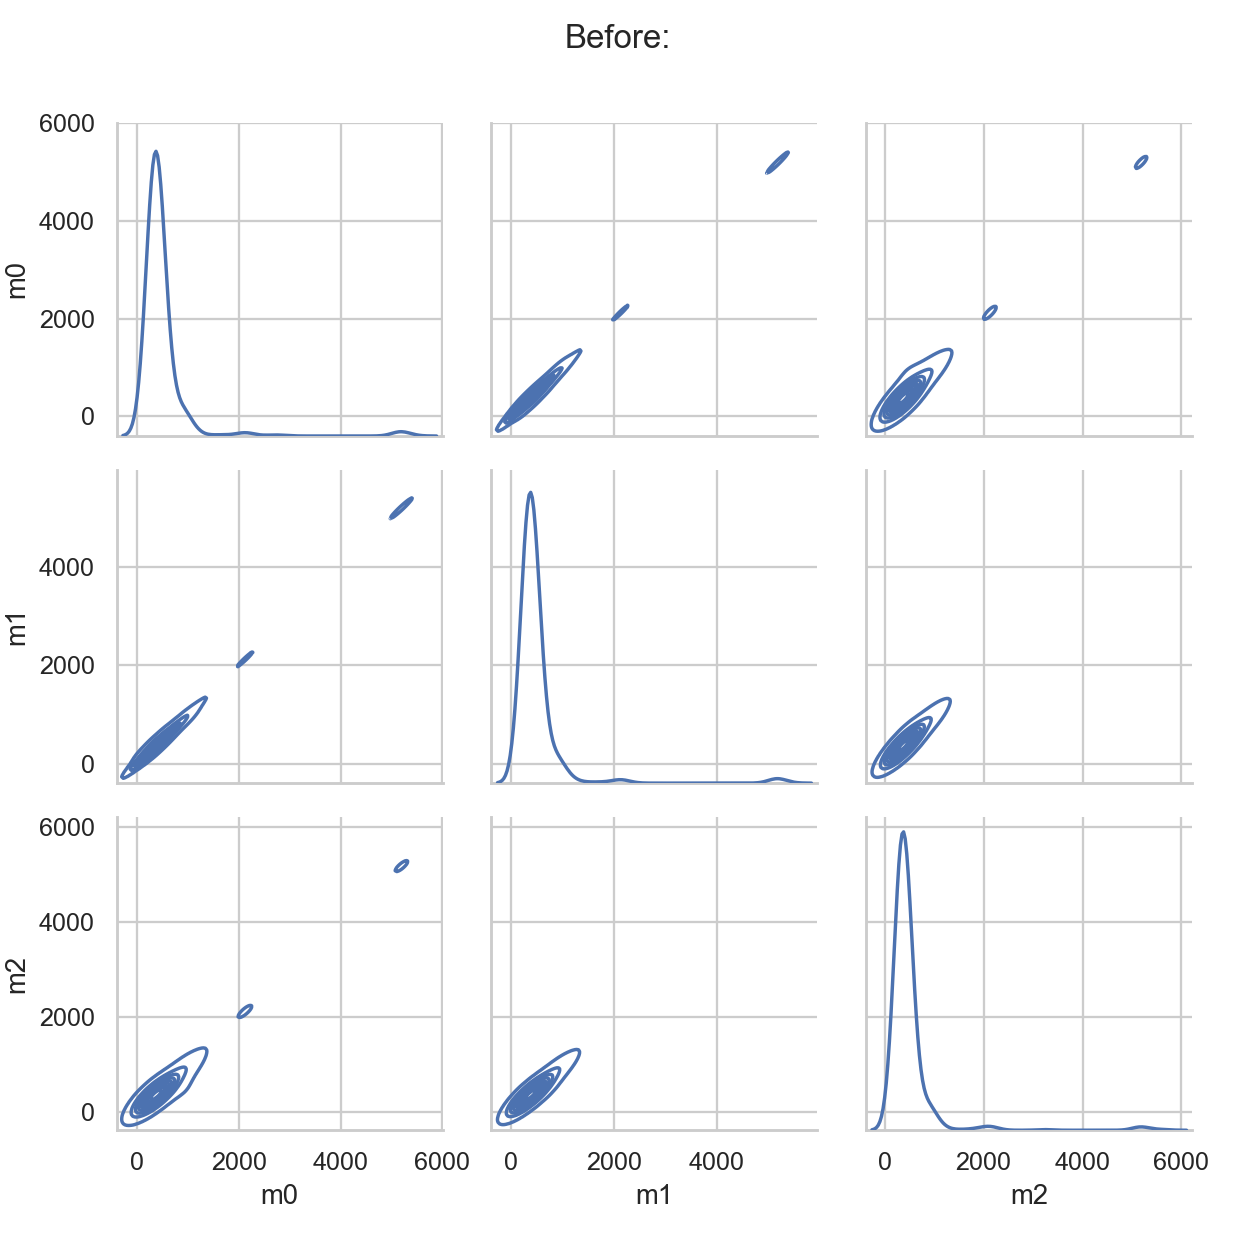

In [19]:
g = sns.PairGrid(X_train.iloc[:,:3].sample(600, random_state=RANDOM_SEED))
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Before:')
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot);
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_B4_sns.kdeplot.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_B4_sns.kdeplot.eps',bbox_inches='tight')

<IPython.core.display.Javascript object>


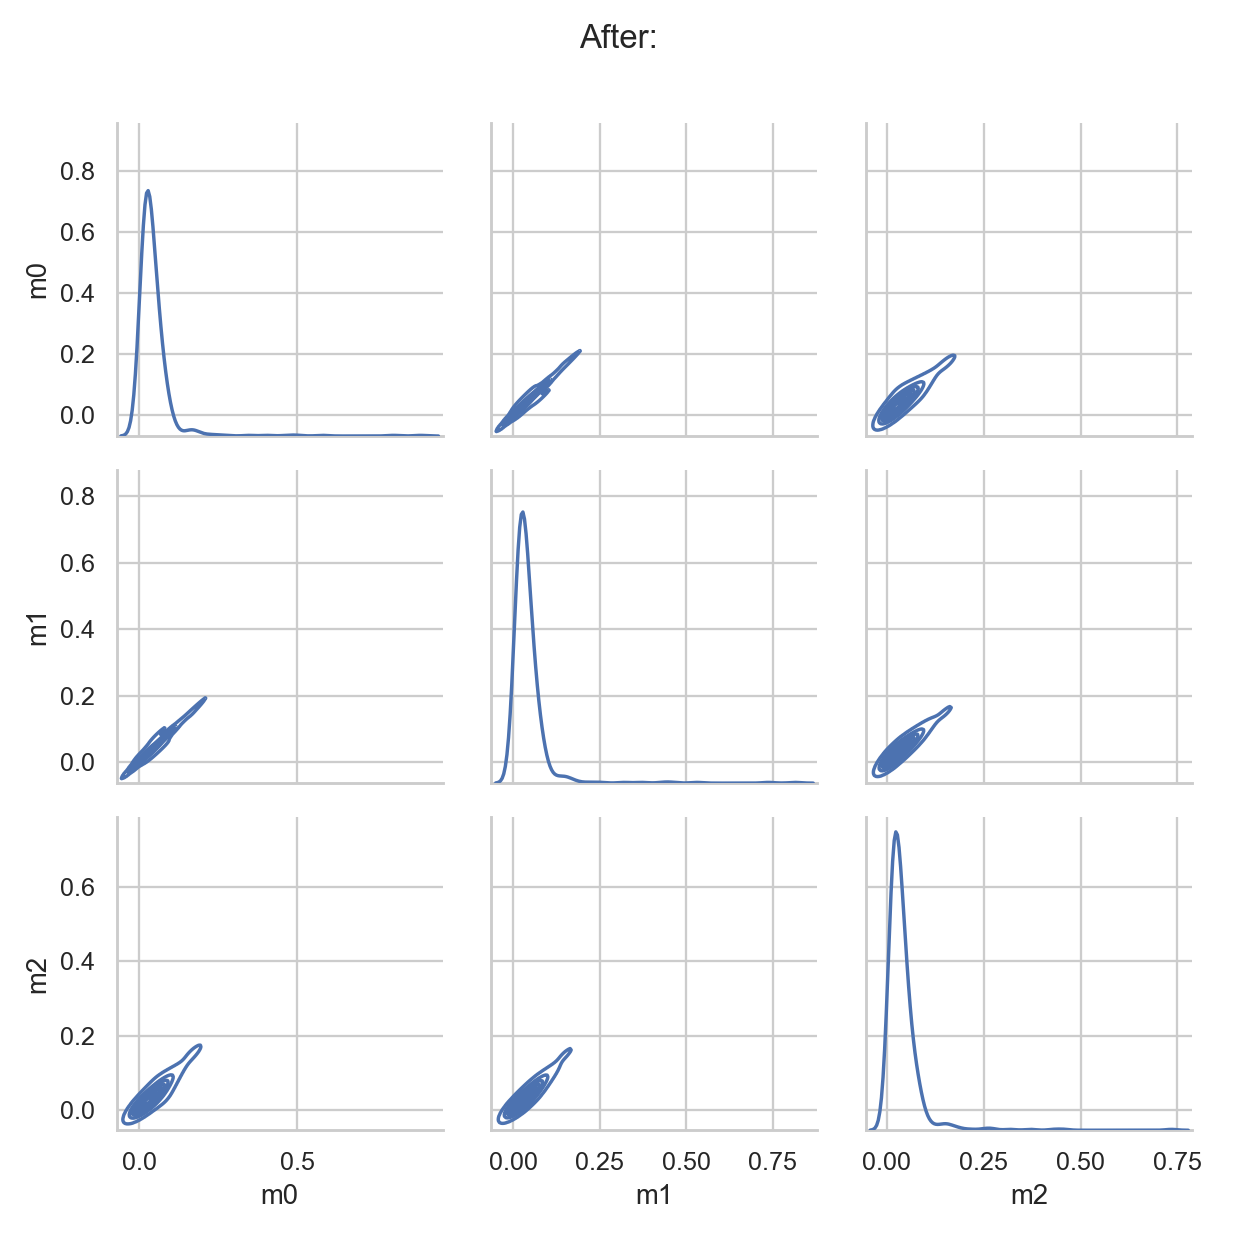

In [20]:
g = sns.PairGrid(pd.DataFrame(X_train_transformed, columns=column_names).iloc[:,:3].sample(600, random_state=RANDOM_SEED))
plt.subplots_adjust(top=0.9)
g.fig.suptitle('After:')
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot);
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_After_sns.kdeplot.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_After_sns.kdeplot.eps',bbox_inches='tight')


Training the auto-encoder

Architecture of our model

In [21]:
# data dimensions // hyperparameters 
input_dim = X_train_transformed.shape[1]
#BATCH_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 100

# https://keras.io/layers/core/
autoencoder = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Dense(input_dim, activation='elu', input_shape=(input_dim, )), 
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(2, activation='elu'),
    
    # reconstruction / decode
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(input_dim, activation='elu')
    
])

# https://keras.io/api/models/model_training_apis/
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary();

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1380)              1905780   
                                                                 
 dense_1 (Dense)             (None, 16)                22096     
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dense_3 (Dense)             (None, 4)                 36        
                                                                 
 dense_4 (Dense)             (None, 2)                 10        
                                                                 
 dense_5 (Dense)             (None, 4)                 12        
                                                                 
 dense_6 (Dense)             (None, 8)                 4

Callbacks

Continue as long as the model is reducing the training loss.
Save only the weights for the model with the lowest validation loss, though.
Get graphical insights with Tensorboard.

In [22]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='autoencoder_best_weights.hdf5',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/{log_subdir}',
    batch_size=BATCH_SIZE,
    update_freq='batch'
)

# callbacks argument only takes a list
#cb = [early_stop, save_model, tensorboard]
cb = [save_model, tensorboard]

Training

In [23]:
history = autoencoder.fit(
    X_train_transformed, X_train_transformed,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(X_validate_transformed, X_validate_transformed)
);

Epoch 1/100
250/250 [==============================] - 10s 32ms/step - loss: 0.0110 - acc: 0.0051 - val_loss: 0.0101 - val_acc: 0.0115
Epoch 2/100
250/250 [==============================] - 6s 24ms/step - loss: 0.0101 - acc: 0.0110 - val_loss: 0.0101 - val_acc: 0.0100
Epoch 3/100
250/250 [==============================] - 8s 31ms/step - loss: 0.0101 - acc: 0.0122 - val_loss: 0.0101 - val_acc: 0.0105
Epoch 4/100
250/250 [==============================] - 8s 30ms/step - loss: 0.0101 - acc: 0.0091 - val_loss: 0.0101 - val_acc: 0.0115
Epoch 5/100
250/250 [==============================] - 8s 31ms/step - loss: 0.0100 - acc: 0.0099 - val_loss: 0.0100 - val_acc: 0.0093
Epoch 6/100
250/250 [==============================] - 7s 30ms/step - loss: 0.0100 - acc: 0.0087 - val_loss: 0.0100 - val_acc: 0.0135
Epoch 7/100
250/250 [==============================] - 8s 31ms/step - loss: 0.0100 - acc: 0.0106 - val_loss: 0.0100 - val_acc: 0.0105
Epoch 8/100
250/250 [==============================] - 8s 31m

Epoch 62/100
250/250 [==============================] - 7s 29ms/step - loss: 0.0089 - acc: 0.0432 - val_loss: 0.0089 - val_acc: 0.0437
Epoch 63/100
250/250 [==============================] - 7s 29ms/step - loss: 0.0089 - acc: 0.0423 - val_loss: 0.0089 - val_acc: 0.0495
Epoch 64/100
250/250 [==============================] - 7s 29ms/step - loss: 0.0089 - acc: 0.0445 - val_loss: 0.0089 - val_acc: 0.0415
Epoch 65/100
250/250 [==============================] - 7s 27ms/step - loss: 0.0088 - acc: 0.0444 - val_loss: 0.0089 - val_acc: 0.0420
Epoch 66/100
250/250 [==============================] - 7s 29ms/step - loss: 0.0089 - acc: 0.0440 - val_loss: 0.0089 - val_acc: 0.0402
Epoch 67/100
250/250 [==============================] - 8s 33ms/step - loss: 0.0089 - acc: 0.0427 - val_loss: 0.0088 - val_acc: 0.0495
Epoch 68/100
250/250 [==============================] - 8s 30ms/step - loss: 0.0088 - acc: 0.0436 - val_loss: 0.0089 - val_acc: 0.0472
Epoch 69/100
250/250 [==============================] -

Reconstructions
We apply the transformation pipeline to our test set.
Then, we pass the data through the trained autoencoder.

In [24]:
# transform the test set with the pipeline fitted to the training set
X_test_transformed = pipeline.transform(X_test)

# pass the transformed test set through the autoencoder to get the reconstructed result
reconstructions = autoencoder.predict(X_test_transformed)

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but Normalizer was fitted with feature names
  warnings.warn(


1018/1018 [==============================] - 5s 4ms/step


Calculate the reconstruction loss for every transaction and draw a sample.

In [25]:
# calculating the mean squared error reconstruction loss per row in the numpy array
mse = np.mean(np.power(X_test_transformed - reconstructions, 2), axis=1)

<IPython.core.display.Javascript object>


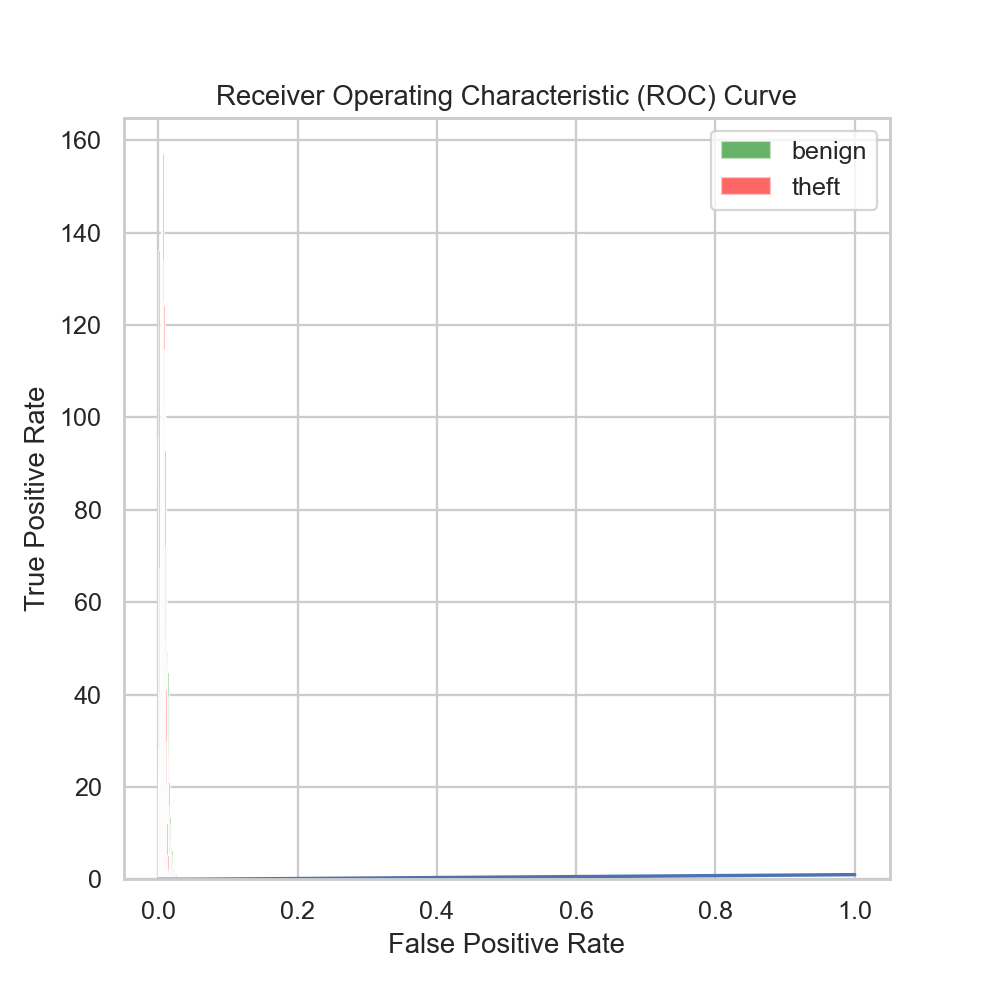

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [26]:
benign = mse[y_test==0]
theft = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(benign, bins=50, density=True, label="benign", alpha=.6, color="green")
ax.hist(theft, bins=50, density=True, label="theft", alpha=.6, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_real_(Normalized) Distribution of the Reconstruction Loss.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_real_(Normalized) Distribution of the Reconstruction Loss.eps',bbox_inches='tight')
plt.show()

Very promising! Although some transactions seem to fool the autoencoder, the fraudulent transactions clearly have a distinguishing element in their data that sets them apart from clean ones.

## Setting a threshold for classification
### Unsupervised
Normally, in an unsupervised solution, this is where the story would end. We would set a threshold that limits the amount of false positives to a manageable degree, and captures the most anomalous data points.

Percentiles:
We could set this threshold by taking the top x% of the dataset and considering it anomalous.

MAD:
We could also use a modified Z-score using the Median Absolute Deviation(MAD) to define outliers on our reconstruction data. Here is a good blog post on the topic by João Rodrigues, illustrating why this algorithm is more robust and scalable than the percentiles method.

In [27]:
#THRESHOLD = 0.0271
#THRESHOLD = 2.71
THRESHOLD = 2.0

def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

z_scores = mad_score(mse)
outliers = z_scores > THRESHOLD

In [28]:
print(f"Detected {np.sum(outliers):,} outliers in a total of {np.size(z_scores):,} transactions [{np.sum(outliers)/np.size(z_scores):.2%}].")

Detected 1,257 outliers in a total of 32,560 transactions [3.86%].


Supervised¶
We know the labels, so we can verify our results.

Classification Matrix on MAD outliers¶
A closer look:

In [29]:
from sklearn.metrics import (confusion_matrix, 
                             precision_recall_curve)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, confusion_matrix

# get (mis)classification
cm = confusion_matrix(y_test, outliers)

# true/false positives/negatives
(tn, fp, 
 fn, tp) = cm.flatten()

######################################################################################
# Use the best threshold for final predictions
#predictions = [int(loss > best_threshold) for loss in losses]

# Calculate performance metrics
accuracy = accuracy_score(y_test, outliers)
precision = precision_score(y_test, outliers)
recall = recall_score(y_test, outliers)
f1 = f1_score(y_test, outliers)
roc_curve_data = roc_curve(y_test, outliers)
#tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
tn, fp, fn, tp = confusion_matrix(y_test, outliers).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
tnr = tn / (tn + fp)

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, outliers)

# Print the results
#print(f"Best Threshold: {best_threshold}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"True Positive Rate: {tpr}")
print(f"False Positive Rate: {fpr}")
print(f"False Negative Rate: {fnr}")
print(f"True Negative Rate: {tnr}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")
print(f"ROC Curve Data: {roc_curve_data}")

#########################################################################################

Accuracy: 0.6930282555282555
Precision: 0.008750994431185362
Recall: 0.0012557077625570776
True Positive Rate: 0.0012557077625570776
False Positive Rate: 0.05235294117647059
False Negative Rate: 0.9987442922374429
True Negative Rate: 0.9476470588235294
F1 Score: 0.0021962663472097433
ROC AUC: 0.4744513832930432
ROC Curve Data: (array([0.        , 0.05235294, 1.        ]), array([0.        , 0.00125571, 1.        ]), array([2, 1, 0]))


In [30]:
print(f"""The classifications using the MAD method with threshold={THRESHOLD} are as follows:
{cm}

% of transactions labeled as theft that were correct (precision): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% of fraudulent transactions were caught succesfully (recall):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}""")

The classifications using the MAD method with threshold=2.0 are as follows:
[[22554  1246]
 [ 8749    11]]

% of transactions labeled as theft that were correct (precision): 11/(1246+11) = 0.88%
% of fraudulent transactions were caught succesfully (recall):    11/(8749+11) = 0.13%


In [31]:
# Plot ROC curve
# Calculate ROC curve
#fpr, tpr, THRESHOLD = roc_curve(y_test, losses)
fpr, tpr, THRESHOLD = roc_curve(y_test, outliers)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.grid(True)
plt.show()

Asymmetric error cost
In the real world, we can expect different costs associated with reporting a false positive versus reporting a false negative. Missing a fraud case is likely to be much more costly than wrongly flagging a transaction as one. In another kernel, I discuss an approach to determining these costs for this dataset in depth.

Recall & Precision
Generally speaking, you will have to prioritise what you find more important. This dilemma is commonly called the "recall vs precision" trade-off. If you want to increase recall, adjust the MAD's Z-Score threshold downwards, if you want recover precision, increase it.

<IPython.core.display.Javascript object>


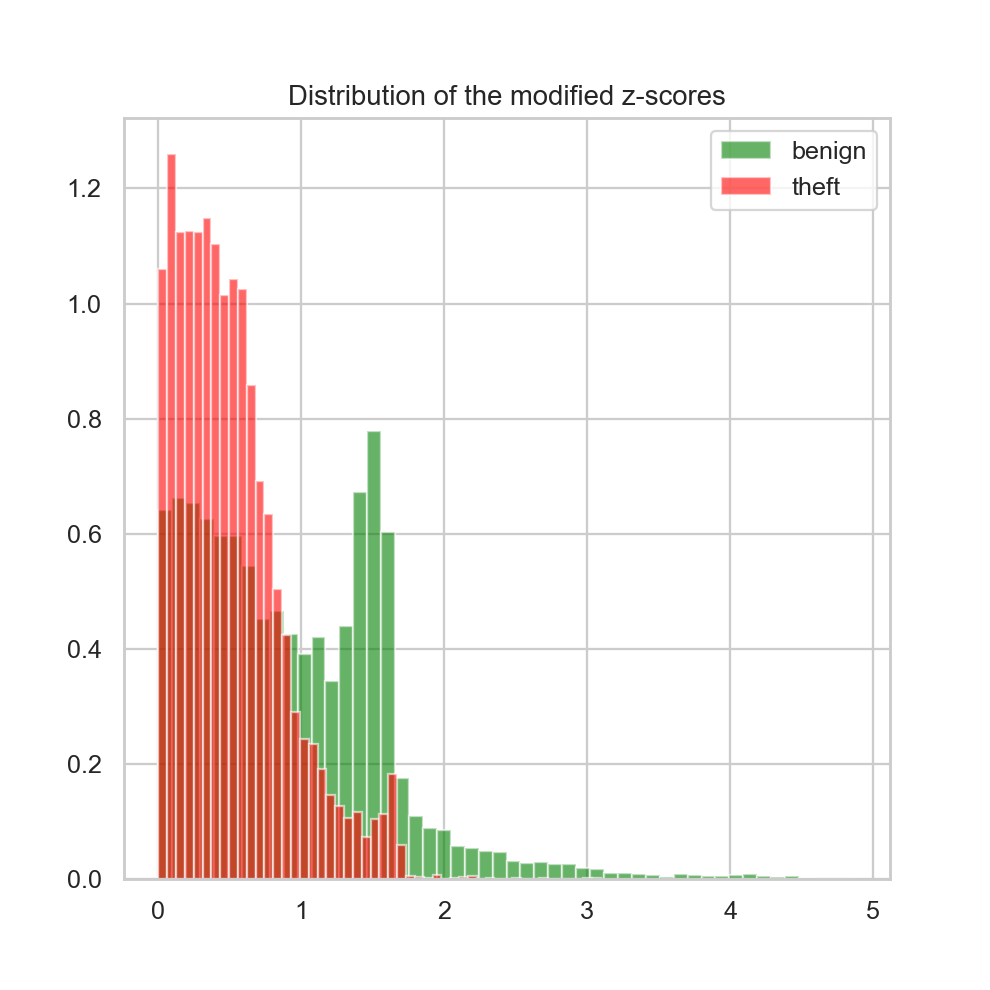

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [32]:
benign = z_scores[y_test==0]
theft = z_scores[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(benign, bins=50, density=True, label="benign", alpha=.6, color="green")
ax.hist(theft, bins=50, density=True, label="theft", alpha=.6, color="red")

plt.title("Distribution of the modified z-scores")
plt.legend()
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_train_Distribution of the modified z-scores.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_train_Distribution of the modified z-scores.eps',bbox_inches='tight')
plt.show()

Latent Space
It is always interesting to look at the compressed representation our neural network devised.

Encoder
Let's build the encoder that gets us to the bottleneck. We take the layers from our autoencoder.

In [33]:
encoder = tf.keras.models.Sequential(autoencoder.layers[:5])
encoder.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1380)              1905780   
                                                                 
 dense_1 (Dense)             (None, 16)                22096     
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dense_3 (Dense)             (None, 4)                 36        
                                                                 
 dense_4 (Dense)             (None, 2)                 10        
                                                                 
Total params: 1,928,058
Trainable params: 1,928,058
Non-trainable params: 0
_________________________________________________________________


Undersampling
Consistent with the previous t-sne visualisation, let's undersample the benign transactions.

In [34]:
# taking all the fraud, undersampling clean
theft = X_test_transformed[y_test==1]
benign = X_test_transformed[y_test==0][:len(theft) * RATIO_TO_THEFT, ]

# combining arrays & building labels
features = np.append(theft, benign, axis=0)
labels = np.append(np.ones(len(theft)),
                   np.zeros(len(benign)))

# getting latent space representation
latent_representation = encoder.predict(features)

print(f'Benign transactions downsampled from {len(X_test_transformed[y_test==0]):,} to {len(benign):,}.')
print('Shape of latent representation:', latent_representation.shape)

822/822 [==============================] - 3s 4ms/step
Benign transactions downsampled from 23,800 to 17,520.
Shape of latent representation: (26280, 2)


Visualising the Latent Space

<IPython.core.display.Javascript object>


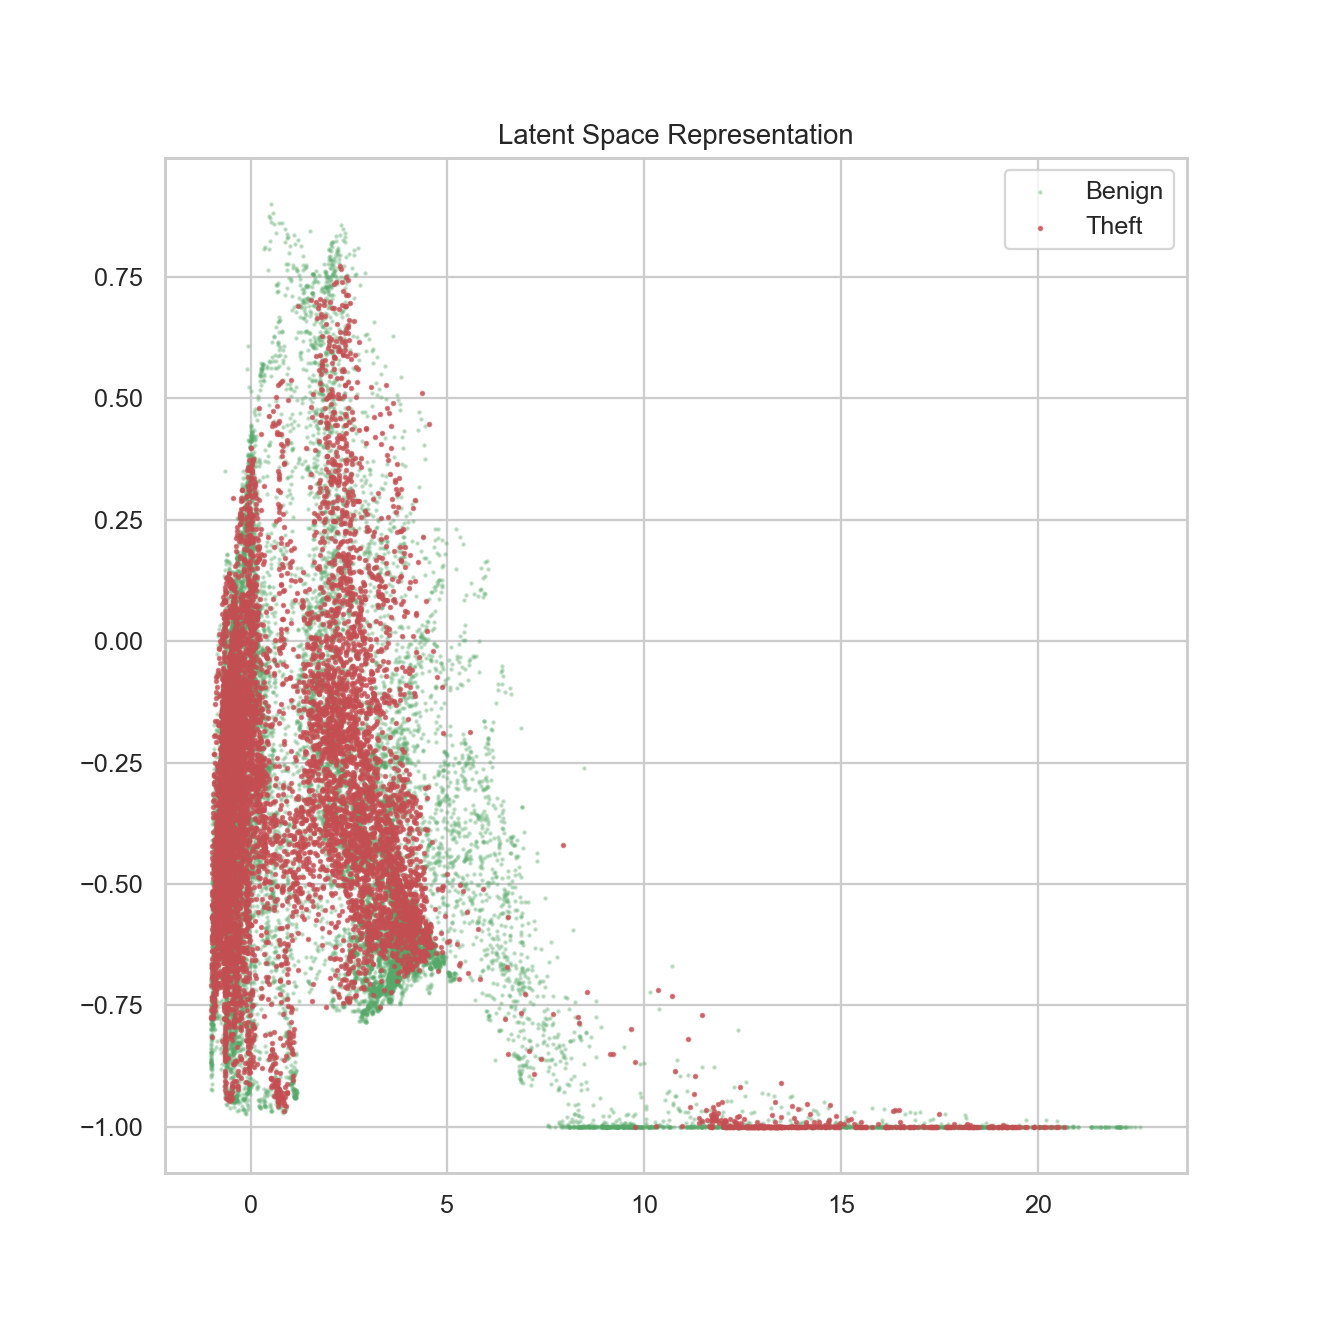

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [35]:
X = latent_representation[:,0]
y = latent_representation[:,1]

# plotting
plt.subplots(figsize=(8, 8))
plt.scatter(X[labels==0], y[labels==0], s=1, c='g', alpha=0.3, label='Benign')
plt.scatter(X[labels==1], y[labels==1], s=2, c='r', alpha=0.7, label='Theft')

# labeling
plt.legend(loc='best')
plt.title('Latent Space Representation')

# saving & displaying
plt.savefig('latent_representation_2d');
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_latent_representation_2d.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_latent_representation_2d.eps',bbox_inches='tight')
plt.show()